In [1]:
# Representa e manipula matrizes
import numpy as np
# Exibe as imagens
import matplotlib.pyplot as plt
# Processamento de Imagens e Visão Computacional
import cv2


# Ler, converter, e redimensionar imagens
from PIL import Image
# Acessa imagens de exemplo
from skimage import data, color, util

In [2]:
def mostrar_imagem(imagem, titulo, cmap=None, barra_cores=False, tamanho=(4,4)):
    # Definindo Tamanho da imagem
    plt.figure(figsize=tamanho);

    plt.imshow(imagem, cmap=cmap, vmin=0, vmax=255)
    plt.title(titulo)
    plt.axis("off")

    if barra_cores:
        plt.colorbar()

    plt.show()

def mostrar_comparacao(imagens, titulos, cmaps=None, tamanho=(16, 6)):
    quantidade = len(imagens)

    if cmaps is None:
        cmaps = [None] * quantidade

    fig, eixos = plt.subplots(1, quantidade, figsize=tamanho)

    if quantidade == 1:
        eixos = [eixos]

    for eixo, imagem, titulo, cmap in zip(eixos, imagens, titulos, cmaps):
        eixo.imshow(imagem, cmap=cmap)
        eixo.set_title(titulo)
        eixo.axis("off")

    plt.tight_layout()
    plt.show()

def mostrar_imagem_histograma(imagem, titulo="Imagem"):
    fig, eixos = plt.subplots(1, 2, figsize=(16,6))

    eixos[0].imshow(imagem, cmap='gray', vmin=0, vmax=255)
    eixos[0].set_title(titulo)
    eixos[0].axis("off")

    eixos[1].hist(
        imagem.ravel(),
        bins = 256,
        range = (0, 255)
    )
    eixos[1].set_title("Histograma")
    eixos[1].set_xlabel("Intensidade")
    eixos[1].set_ylabel("Quantidade de Pixels")

    plt.show()

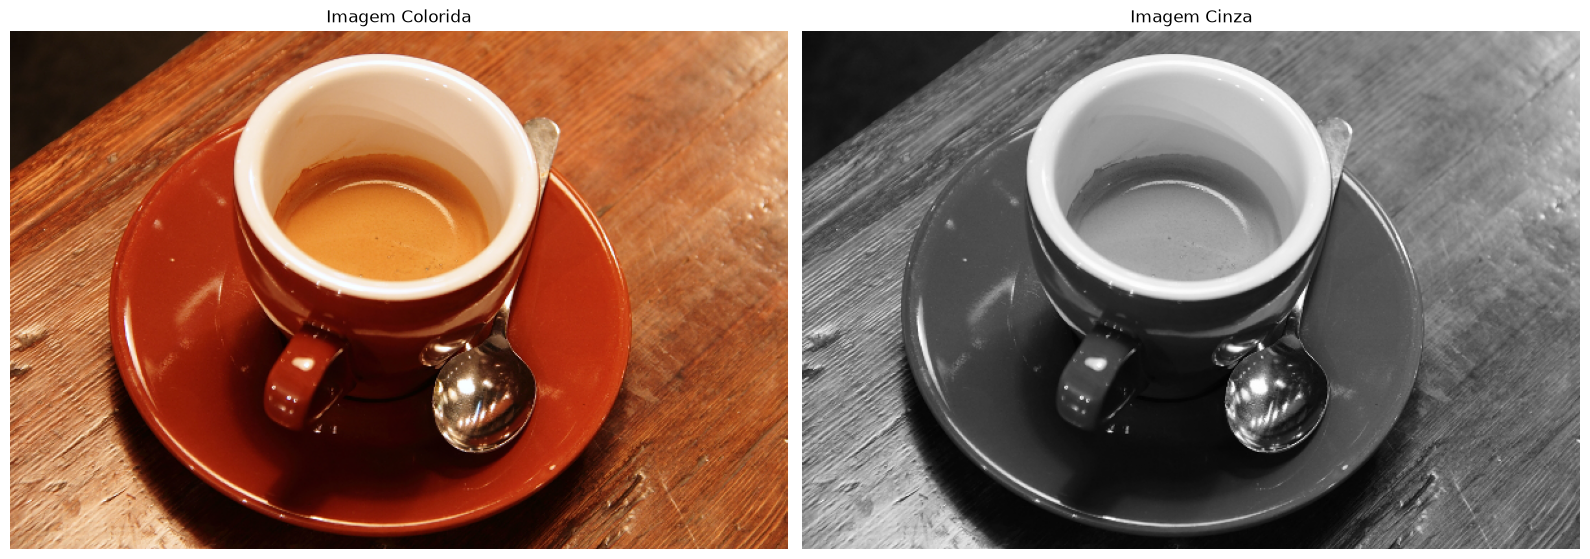

In [4]:
imagem_rgb = data.coffee()

imagem_cinza = (
    0.299 * imagem_rgb[:,:,0] +
    0.587 * imagem_rgb[:,:,1] +
    0.114 * imagem_rgb[:,:,2] 
).astype(np.uint8)

mostrar_comparacao(
    [imagem_rgb, imagem_cinza],
    ['Imagem Colorida', 'Imagem Cinza'],
    [None, "gray"]
)

# Ruído Gaussiano

In [5]:
# Media - Valores variam ao redor da média
# Desvio - Até a onde os valores podem ir
# Semente - Valor utilizado para geração "Aleatória" dos números
def gerar_ruido_gaussiano(imagem, media=0, desvio=20, semente=42):
    # Cria um gerador de valores "aleatórios"
    # Gera sempre a mesma sequência dependendo da semente
    gerador = np.random.default_rng(semente)

    # Gerar valores aleatórios seguindo uma distribuição normal
    ruido = gerador.normal(
        media,
        desvio,
        imagem.shape # Sempre em tons de cinza
    )

    # Adicionando ruídos de -20 à 20, a imagem original
    resultado = imagem.astype(np.float32) + ruido


    return np.clip(
        resultado,
        0,
        255
    ).astype(np.uint8)

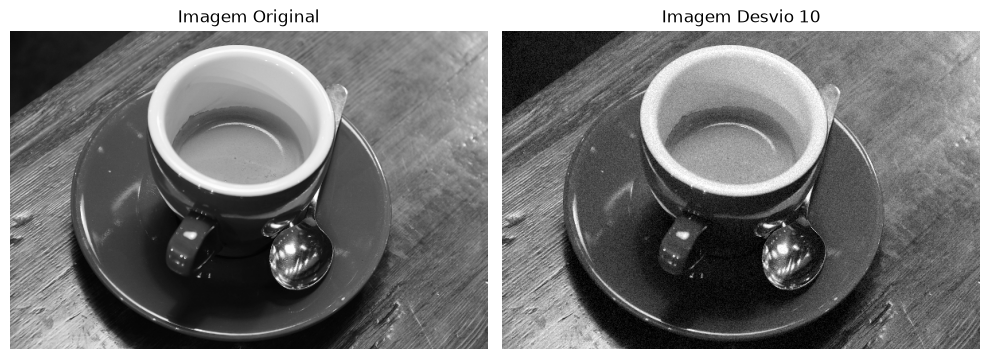

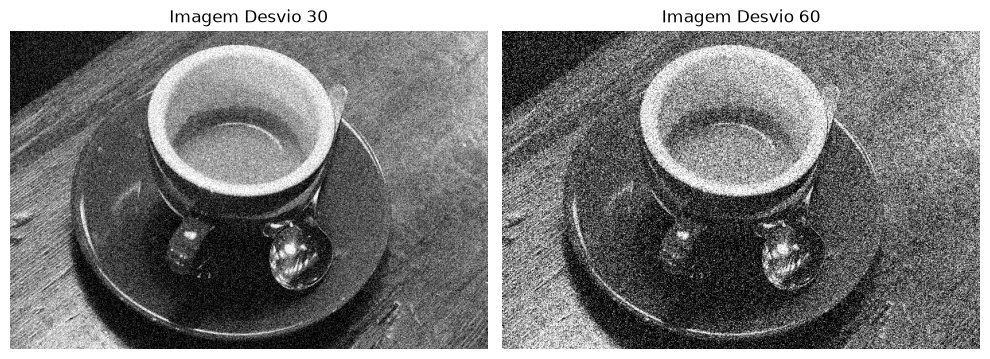

In [7]:
ruido_gaus_10 = gerar_ruido_gaussiano(
    imagem_cinza,
    desvio=10
)
ruido_gaus_30 = gerar_ruido_gaussiano(
    imagem_cinza,
    desvio=30
)
ruido_gaus_60 = gerar_ruido_gaussiano(
    imagem_cinza,
    desvio=60
)

mostrar_comparacao(
    [
        imagem_cinza,
        ruido_gaus_10,
    ],
    [
        "Imagem Original",
        "Imagem Desvio 10",
    ],
    ["gray"]*2,
    tamanho=(10,5)
)

mostrar_comparacao(
    [
        ruido_gaus_30,
        ruido_gaus_60,
    ],
    [
        "Imagem Desvio 30",
        "Imagem Desvio 60",
    ],
    ["gray"] * 2,
    tamanho=(10,5)
)



# Ruído Sal e Pimenta

In [8]:
# Proporção - porcentagem de pixels que terão ruído
# Proporção Sal - Dentro da porcentagem de pixels com ruído, quantos serão Sal(PIxel Branco)
def gerar_ruido_sal_pimenta(imagem, proporcao=0.05, propocao_sal=0.5, semente=42):
    # Cria um gerador de valores "aleatórios"
    # Gera sempre a mesma sequência dependendo da semente
    gerador = np.random.default_rng(semente)

    # Cria uma cópia da imagem para alteração de valores 
    resultado = imagem.copy()

    # Passar em tons de cinza
    quantidade_pixels = imagem.size 

    # Quantidade de pixels com ruídos
    quantidade_ruidosa = int(proporcao * quantidade_pixels)

    # Quantidade de pixels brancos
    quantidade_sal = int(propocao_sal * quantidade_ruidosa)

    # Quantidade de pixels pretos
    quantidade_pimenta = (
        quantidade_ruidosa - quantidade_sal
    )

    # Gerar uma matriz de coordenadas que vai receber o pixel branco
    cordenada_sal = (
        # Primeiro e Segundo - Intervalo de valores gerados
        gerador.integers(0, imagem.shape[0], quantidade_sal),
        gerador.integers(0, imagem.shape[1], quantidade_sal)
    )
    # Gerar uma matriz de coordenadas que vai receber o pixel preto
    cordenada_pimenta = (
        # Primeiro e Segundo - Intervalo de valores gerados
        gerador.integers(0, imagem.shape[0], quantidade_pimenta),
        gerador.integers(0, imagem.shape[1], quantidade_pimenta)
    )

    # Pega a imagem cópia e nas cordenadas específicas, altera os valores
    resultado[cordenada_sal] = 255
    resultado[cordenada_pimenta] = 0

    return resultado


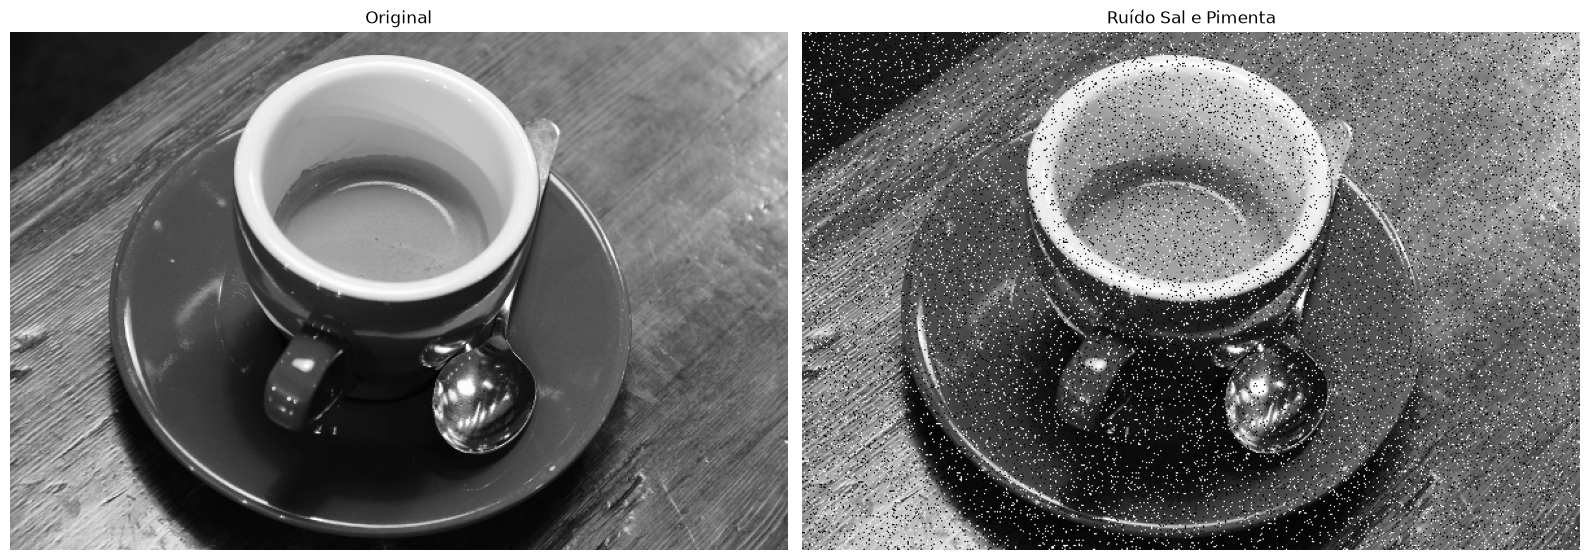

In [10]:
ruido_sal_pimenta = gerar_ruido_sal_pimenta(
    imagem_cinza,
    proporcao=0.1
)

mostrar_comparacao(
    [imagem_cinza, ruido_sal_pimenta],
    ['Original', 'Ruído Sal e Pimenta'],
    ["gray"] * 2
)

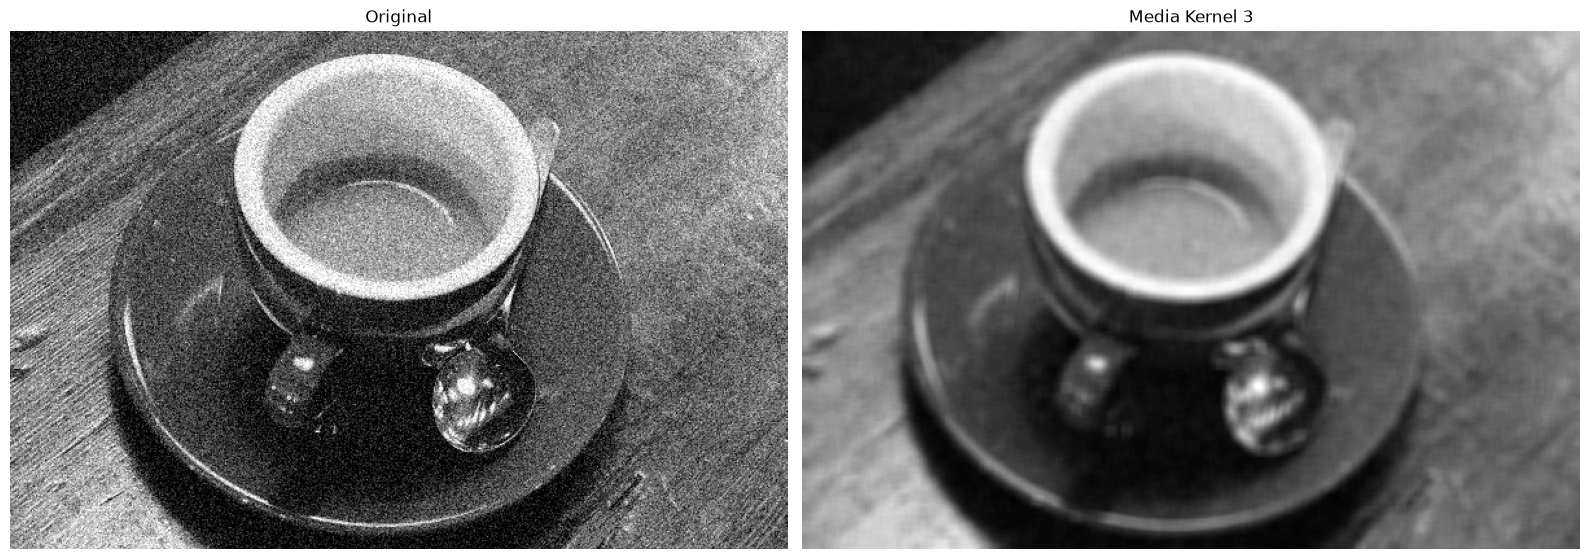

In [13]:
# Blur - Aplica um filtro de média
# Sempre acha a média do valor central e vai para a próxima coluna
media3 = cv2.blur(
    ruido_gaus_30,
    (9,9)
)

mostrar_comparacao(
    [ruido_gaus_30, media3],
    ['Original', 'Media Kernel 3'],
    ["gray"] *2
)